# 02 AfD Polling Preparation (DAWUM)

Goal: build a clean monthly AfD Bundestag polling series from DAWUM for later merge with media salience indicators.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'polling' / 'raw'
PROCESSED_DIR = DATA_DIR / 'polling' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '02_notebook_figures'

for d in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_POLL_PATH = RAW_DIR / 'afd_polling_raw_dawum.csv'
POLL_LEVEL_CSV_PATH = PROCESSED_DIR / 'afd_bundestag_polls_dawum.csv'
POLL_LEVEL_PARQUET_PATH = PROCESSED_DIR / 'afd_bundestag_polls_dawum.parquet'
MONTHLY_CSV_PATH = PROCESSED_DIR / 'afd_polling_monthly.csv'
MONTHLY_PARQUET_PATH = PROCESSED_DIR / 'afd_polling_monthly.parquet'
MONTHLY_ANALYSIS_CSV_PATH = PROCESSED_DIR / 'afd_polling_monthly_2017_2025.csv'
MONTHLY_ANALYSIS_PARQUET_PATH = PROCESSED_DIR / 'afd_polling_monthly_2017_2025.parquet'

ANALYSIS_START = pd.Timestamp('2017-01-01')
ANALYSIS_END = pd.Timestamp('2025-12-31')

AUTO_FETCH_DAWUM = False
DAWUM_API_URL = 'https://api.dawum.de/'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_POLL_PATH:', RAW_POLL_PATH)
print('POLL_LEVEL_CSV_PATH:', POLL_LEVEL_CSV_PATH)
print('MONTHLY_CSV_PATH:', MONTHLY_CSV_PATH)
print('MONTHLY_ANALYSIS_CSV_PATH:', MONTHLY_ANALYSIS_CSV_PATH)
print('ANALYSIS_WINDOW:', ANALYSIS_START.date(), 'to', ANALYSIS_END.date())
print('FIGURES_DIR:', FIGURES_DIR)

PROJECT_ROOT: c:\PythonProjects\AfD-project
RAW_POLL_PATH: c:\PythonProjects\AfD-project\data\polling\raw\afd_polling_raw_dawum.csv
POLL_LEVEL_CSV_PATH: c:\PythonProjects\AfD-project\data\polling\processed\afd_bundestag_polls_dawum.csv
MONTHLY_CSV_PATH: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly.csv
MONTHLY_ANALYSIS_CSV_PATH: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly_2017_2025.csv
ANALYSIS_WINDOW: 2017-01-01 to 2025-12-31
FIGURES_DIR: c:\PythonProjects\AfD-project\figures\02_notebook_figures


## 1) DAWUM JSON Diagnostics

In [2]:
diag_resp = requests.get(
    DAWUM_API_URL,
    headers={'User-Agent': 'AfD-project/1.0 (Notebook02 diagnostics)'},
    timeout=60,
)
diag_resp.raise_for_status()
diag_data = diag_resp.json()

print('Top-level keys:', list(diag_data.keys()))
for key in ['Database', 'Parliaments', 'Institutes', 'Taskers', 'Methods', 'Parties', 'Surveys']:
    block = diag_data.get(key)
    block_len = len(block) if hasattr(block, '__len__') else 'NA'
    print(f"{key}: type={type(block).__name__}, len={block_len}")

surveys_block = diag_data.get('Surveys', {})
if not isinstance(surveys_block, dict) or len(surveys_block) == 0:
    raise RuntimeError('DAWUM diagnostics failed: Surveys block is empty or not a dict.')

example_survey_id, example_survey = next(iter(surveys_block.items()))
print('Example survey id:', example_survey_id)
print('Example survey keys:', list(example_survey.keys()))
print('Example survey record (truncated):')
print(json.dumps(example_survey, indent=2, ensure_ascii=False)[:3000])

Top-level keys: ['Database', 'Parliaments', 'Institutes', 'Taskers', 'Methods', 'Parties', 'Surveys']
Database: type=dict, len=4
Parliaments: type=dict, len=18
Institutes: type=dict, len=22
Taskers: type=dict, len=112
Methods: type=dict, len=6
Parties: type=dict, len=26
Surveys: type=dict, len=3804
Example survey id: 4176
Example survey keys: ['Date', 'Survey_Period', 'Surveyed_Persons', 'Parliament_ID', 'Institute_ID', 'Tasker_ID', 'Method_ID', 'Results']
Example survey record (truncated):
{
  "Date": "2026-05-09",
  "Survey_Period": {
    "Date_Start": "2026-05-04",
    "Date_End": "2026-05-08"
  },
  "Surveyed_Persons": "1200",
  "Parliament_ID": "0",
  "Institute_ID": "5",
  "Tasker_ID": "3",
  "Method_ID": "4",
  "Results": {
    "7": 28,
    "1": 23,
    "2": 13,
    "4": 13,
    "5": 11,
    "0": 6,
    "3": 3,
    "23": 3
  }
}


## 2) Fetch and Flatten DAWUM

One output row = one survey-party result.

In [3]:
def _to_dict(value):
    return value if isinstance(value, dict) else {}


def _coerce_int(value):
    try:
        return int(str(value))
    except Exception:
        return None


def _lookup_value(block: dict, item_id, field: str, default=np.nan):
    if item_id is None or (isinstance(item_id, float) and np.isnan(item_id)):
        return default

    candidates = [item_id]
    s = str(item_id)
    candidates.append(s)
    i = _coerce_int(item_id)
    if i is not None:
        candidates.extend([i, str(i)])

    for key in candidates:
        if key in block and isinstance(block[key], dict):
            return block[key].get(field, default)
    return default


def _extract_survey_period(period_obj):
    if isinstance(period_obj, dict):
        return period_obj.get('Date_Start'), period_obj.get('Date_End')

    if isinstance(period_obj, str) and period_obj.strip():
        val = period_obj.strip()
        if ' - ' in val:
            left, right = val.split(' - ', 1)
            return left.strip(), right.strip()
        if '-' in val and len(val.split('-')) == 2:
            left, right = val.split('-', 1)
            return left.strip(), right.strip()

    return None, None


def fetch_and_flatten_dawum(api_url: str):
    response = requests.get(
        api_url,
        headers={'User-Agent': 'AfD-project/1.0 (Notebook02 fetch)'},
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()

    parliaments = _to_dict(payload.get('Parliaments'))
    institutes = _to_dict(payload.get('Institutes'))
    taskers = _to_dict(payload.get('Taskers'))
    methods = _to_dict(payload.get('Methods'))
    parties = _to_dict(payload.get('Parties'))
    surveys = _to_dict(payload.get('Surveys'))

    if not surveys:
        raise RuntimeError(
            'DAWUM parser error: Surveys block is empty. '
            f"Top-level keys: {list(payload.keys())}"
        )

    rows = []
    for survey_id, survey in surveys.items():
        if not isinstance(survey, dict):
            continue

        parliament_id = survey.get('Parliament_ID')
        institute_id = survey.get('Institute_ID')
        tasker_id = survey.get('Tasker_ID')
        method_id = survey.get('Method_ID')

        published_date = survey.get('Date')
        fieldwork_start, fieldwork_end = _extract_survey_period(survey.get('Survey_Period'))
        sample_size = survey.get('Surveyed_Persons')
        if sample_size in (None, ''):
            sample_size = survey.get('SampleSize')

        results = survey.get('Results', {})
        if not isinstance(results, dict):
            continue

        for party_id, pct in results.items():
            rows.append({
                'survey_id': str(survey_id),
                'parliament_id': parliament_id,
                'parliament': _lookup_value(parliaments, parliament_id, 'Name'),
                'parliament_shortcut': _lookup_value(parliaments, parliament_id, 'Shortcut'),
                'pollster': _lookup_value(institutes, institute_id, 'Name'),
                'tasker': _lookup_value(taskers, tasker_id, 'Name'),
                'method': _lookup_value(methods, method_id, 'Name'),
                'published_date': published_date,
                'fieldwork_start': fieldwork_start,
                'fieldwork_end': fieldwork_end,
                'sample_size': sample_size,
                'party_id': party_id,
                'party': _lookup_value(parties, party_id, 'Shortcut'),
                'party_name': _lookup_value(parties, party_id, 'Name'),
                'pct': pct,
                'source': 'DAWUM',
            })

    raw = pd.DataFrame(rows)
    if raw.empty:
        sample_sid, sample_survey = next(iter(surveys.items()))
        raise RuntimeError(
            'DAWUM parser produced empty raw dataframe. '
            'Schema assumptions did not match DAWUM JSON. '
            f"Top-level keys: {list(payload.keys())}; sample survey id: {sample_sid}; "
            f"sample survey keys: {list(sample_survey.keys())}"
        )

    raw['pct'] = pd.to_numeric(raw['pct'], errors='coerce')
    raw['sample_size'] = pd.to_numeric(raw['sample_size'], errors='coerce')
    for c in ['published_date', 'fieldwork_start', 'fieldwork_end']:
        raw[c] = pd.to_datetime(raw[c], errors='coerce')

    return raw, payload

In [4]:
required_raw_columns = {
    'survey_id', 'parliament_id', 'parliament', 'parliament_shortcut', 'pollster', 'tasker',
    'method', 'published_date', 'fieldwork_start', 'fieldwork_end', 'sample_size',
    'party_id', 'party', 'party_name', 'pct', 'source'
}

if AUTO_FETCH_DAWUM or not RAW_POLL_PATH.exists():
    raw, raw_payload = fetch_and_flatten_dawum(DAWUM_API_URL)
else:
    raw = pd.read_csv(RAW_POLL_PATH)
    raw_payload = None
    raw['pct'] = pd.to_numeric(raw.get('pct'), errors='coerce')
    raw['sample_size'] = pd.to_numeric(raw.get('sample_size'), errors='coerce')
    for c in ['published_date', 'fieldwork_start', 'fieldwork_end']:
        if c in raw.columns:
            raw[c] = pd.to_datetime(raw[c], errors='coerce')

if raw.empty:
    if raw_payload is not None:
        surveys = raw_payload.get('Surveys', {}) if isinstance(raw_payload, dict) else {}
        sample_survey = next(iter(surveys.values())) if isinstance(surveys, dict) and surveys else {}
        raise RuntimeError(
            'Raw dataframe is empty after fetch/flatten. '
            f"Available keys: {list(raw_payload.keys()) if isinstance(raw_payload, dict) else 'NA'}; "
            f"sample survey: {sample_survey}"
        )
    raise RuntimeError('Raw dataframe is empty and no payload diagnostics are available.')

missing = required_raw_columns - set(raw.columns)
if missing:
    raise ValueError(f'Missing required raw columns: {sorted(missing)}')

if raw['pct'].notna().sum() == 0:
    raise ValueError('pct is fully non-numeric after coercion. Parser assumptions likely wrong.')

raw.to_csv(RAW_POLL_PATH, index=False)
print('Saved raw file:', RAW_POLL_PATH)
print('raw.shape:', raw.shape)
print('raw.head():')
print(raw.head())
print('Top parliaments:')
print(raw['parliament'].value_counts(dropna=False).head(20))
print('Top parties:')
print(raw['party'].value_counts(dropna=False).head(20))
print('Top pollsters:')
print(raw['pollster'].value_counts(dropna=False).head(20))

Saved raw file: c:\PythonProjects\AfD-project\data\polling\raw\afd_polling_raw_dawum.csv
raw.shape: (28069, 16)
raw.head():
   survey_id  parliament_id parliament parliament_shortcut        pollster tasker       method published_date fieldwork_start fieldwork_end  sample_size  party_id    party  \
0       4174              0  Bundestag           Bundestag  Verian (Emnid)  FOCUS  Telefonisch     2026-05-08      2026-04-28    2026-05-05         1448         7      AfD   
1       4174              0  Bundestag           Bundestag  Verian (Emnid)  FOCUS  Telefonisch     2026-05-08      2026-04-28    2026-05-05         1448         1  CDU/CSU   
2       4174              0  Bundestag           Bundestag  Verian (Emnid)  FOCUS  Telefonisch     2026-05-08      2026-04-28    2026-05-05         1448         4    Grüne   
3       4174              0  Bundestag           Bundestag  Verian (Emnid)  FOCUS  Telefonisch     2026-05-08      2026-04-28    2026-05-05         1448         2      SPD   
4

## 3) Filter to Bundestag + AfD, then build poll-level dataset

In [5]:
party_short = raw['party'].astype(str).str.strip().str.lower()
party_name = raw['party_name'].astype(str).str.strip().str.lower()
parl_name = raw['parliament'].astype(str).str.strip().str.lower()
parl_short = raw['parliament_shortcut'].astype(str).str.strip().str.lower()

afd_mask = party_short.eq('afd') | party_name.str.contains('alternative', na=False)
bundestag_mask = parl_name.str.contains('bundestag', na=False) | parl_short.str.contains('bundestag', na=False)

polls = raw.loc[afd_mask & bundestag_mask].copy()

if polls.empty:
    raise RuntimeError(
        'Bundestag + AfD filter returned zero rows. '
        'Check parliament and party value counts in raw diagnostics.'
    )

for c in ['published_date', 'fieldwork_start', 'fieldwork_end']:
    polls[c] = pd.to_datetime(polls[c], errors='coerce')

polls['pct'] = pd.to_numeric(polls['pct'], errors='coerce')
polls = polls.sort_values(['published_date', 'survey_id']).reset_index(drop=True)

polls.to_csv(POLL_LEVEL_CSV_PATH, index=False)
polls.to_parquet(POLL_LEVEL_PARQUET_PATH, index=False)

print('Saved poll-level CSV:', POLL_LEVEL_CSV_PATH)
print('Saved poll-level parquet:', POLL_LEVEL_PARQUET_PATH)
print('polls.shape:', polls.shape)
print('date range:', polls['published_date'].min(), 'to', polls['published_date'].max())
print('unique surveys:', polls['survey_id'].nunique())
print('Pollsters by frequency:')
print(polls['pollster'].value_counts(dropna=False).head(20))
print('Missing fieldwork_start:', int(polls['fieldwork_start'].isna().sum()))
print('Missing fieldwork_end:', int(polls['fieldwork_end'].isna().sum()))
print('Missing sample_size:', int(polls['sample_size'].isna().sum()))
print('pct describe:')
print(polls['pct'].describe())

Saved poll-level CSV: c:\PythonProjects\AfD-project\data\polling\processed\afd_bundestag_polls_dawum.csv
Saved poll-level parquet: c:\PythonProjects\AfD-project\data\polling\processed\afd_bundestag_polls_dawum.parquet
polls.shape: (2571, 16)
date range: 2017-01-18 00:00:00 to 2026-05-08 00:00:00
unique surveys: 2571
Pollsters by frequency:
pollster
INSA                          745
Forsa                         478
Verian (Emnid)                380
Infratest dimap               202
Forschungsgruppe Wahlen       182
YouGov                        125
Allensbach                    116
Civey                         113
GMS                            79
Ipsos                          74
Institut Wahlkreisprognose     60
pollytix                       10
Trend Research Hamburg          7
Name: count, dtype: int64
Missing fieldwork_start: 0
Missing fieldwork_end: 0
Missing sample_size: 0
pct describe:
count    2571.000000
mean       14.843602
std         5.112230
min         6.500000
25%     

## 4) Construct analysis date and aggregate monthly

In [6]:
work = polls.copy()

midpoint_mask = work['fieldwork_start'].notna() & work['fieldwork_end'].notna()
work['poll_date'] = pd.NaT
work.loc[midpoint_mask, 'poll_date'] = work.loc[midpoint_mask, 'fieldwork_start'] + (
    work.loc[midpoint_mask, 'fieldwork_end'] - work.loc[midpoint_mask, 'fieldwork_start']
) / 2
work['poll_date'] = work['poll_date'].fillna(work['fieldwork_end'])
work['poll_date'] = work['poll_date'].fillna(work['published_date'])

if work['poll_date'].isna().all():
    raise RuntimeError('All poll_date values are missing after fallback logic.')

work['month_dt'] = work['poll_date'].dt.to_period('M').dt.to_timestamp()
work['year_month'] = work['month_dt'].dt.strftime('%Y-%m')
work['year'] = work['month_dt'].dt.year
work['month_num'] = work['month_dt'].dt.month
work['month'] = work['year_month']

monthly = (
    work.groupby(['month', 'year_month', 'month_dt', 'year', 'month_num'], as_index=False)
    .agg(
        afd_poll_support_mean=('pct', 'mean'),
        afd_poll_support_median=('pct', 'median'),
        afd_poll_support_min=('pct', 'min'),
        afd_poll_support_max=('pct', 'max'),
        afd_poll_support_sd=('pct', 'std'),
        n_polls=('survey_id', 'nunique'),
        n_pollsters=('pollster', 'nunique'),
        first_poll_date=('poll_date', 'min'),
        last_poll_date=('poll_date', 'max'),
    )
    .sort_values('month_dt')
    .reset_index(drop=True)
)

monthly['afd_poll_support_sd'] = monthly['afd_poll_support_sd'].fillna(0.0)
monthly['source'] = 'DAWUM'

monthly.to_csv(MONTHLY_CSV_PATH, index=False)
monthly.to_parquet(MONTHLY_PARQUET_PATH, index=False)

print('Saved monthly CSV:', MONTHLY_CSV_PATH)
print('Saved monthly parquet:', MONTHLY_PARQUET_PATH)
print('monthly.shape:', monthly.shape)
print(monthly.head())

Saved monthly CSV: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly.csv
Saved monthly parquet: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly.parquet
monthly.shape: (113, 15)
     month year_month   month_dt  year  month_num  afd_poll_support_mean  afd_poll_support_median  afd_poll_support_min  afd_poll_support_max  afd_poll_support_sd  n_polls  \
0  2017-01    2017-01 2017-01-01  2017          1              12.186667                     12.0                  11.0                  14.5             1.139465       15   
1  2017-02    2017-02 2017-02-01  2017          2              10.356522                     10.0                   8.0                  13.0             1.374715       23   
2  2017-03    2017-03 2017-03-01  2017          3               9.529167                      9.2                   7.0                  11.5             1.408508       24   
3  2017-04    2017-04 2017-04-01  2017          4               9.064286   

## 6) Create analysis-window polling dataset

In [7]:
required_monthly_columns = [
    'month',
    'year_month',
    'month_dt',
    'year',
    'month_num',
    'afd_poll_support_mean',
    'afd_poll_support_median',
    'afd_poll_support_min',
    'afd_poll_support_max',
    'afd_poll_support_sd',
    'n_polls',
    'n_pollsters',
    'first_poll_date',
    'last_poll_date',
    'source',
]

missing_monthly_cols = [c for c in required_monthly_columns if c not in monthly.columns]
if missing_monthly_cols:
    raise ValueError(f'Monthly output is missing required columns: {missing_monthly_cols}')

monthly['month_dt'] = pd.to_datetime(monthly['month_dt'], errors='coerce')
monthly_analysis = monthly[(monthly['month_dt'] >= ANALYSIS_START) & (monthly['month_dt'] <= ANALYSIS_END)].copy()
monthly_analysis = monthly_analysis.sort_values('month_dt').reset_index(drop=True)

if monthly_analysis['month'].duplicated().any():
    dupes = monthly_analysis.loc[monthly_analysis['month'].duplicated(), 'month'].tolist()
    raise ValueError(f'Duplicate month values in analysis dataset: {dupes[:10]}')

expected_months = pd.period_range(ANALYSIS_START, ANALYSIS_END, freq='M')
actual_months = pd.PeriodIndex(monthly_analysis['month_dt'].dropna().dt.to_period('M').unique(), freq='M')
missing_months = expected_months.difference(actual_months)
expected_count = len(expected_months)
actual_count = len(monthly_analysis)

if len(missing_months) > 0:
    raise ValueError(
        'Analysis-window monthly dataset has missing months: '
        + ', '.join(m.strftime('%Y-%m') for m in missing_months[:20])
    )

if actual_count != expected_count:
    raise ValueError(
        f'Analysis-window row count mismatch: expected {expected_count}, got {actual_count}'
    )

monthly_analysis.to_csv(MONTHLY_ANALYSIS_CSV_PATH, index=False)
monthly_analysis.to_parquet(MONTHLY_ANALYSIS_PARQUET_PATH, index=False)

print('Saved analysis-window CSV:', MONTHLY_ANALYSIS_CSV_PATH)
print('Saved analysis-window parquet:', MONTHLY_ANALYSIS_PARQUET_PATH)
print('Full monthly coverage:', monthly['month_dt'].min(), 'to', monthly['month_dt'].max(), '| rows =', len(monthly))
print('Analysis coverage:', monthly_analysis['month_dt'].min(), 'to', monthly_analysis['month_dt'].max(), '| rows =', len(monthly_analysis))
print('Expected rows:', expected_count)
print('Missing months in analysis window:', [m.strftime('%Y-%m') for m in missing_months])

Saved analysis-window CSV: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly_2017_2025.csv
Saved analysis-window parquet: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly_2017_2025.parquet
Full monthly coverage: 2017-01-01 00:00:00 to 2026-05-01 00:00:00 | rows = 113
Analysis coverage: 2017-01-01 00:00:00 to 2025-12-01 00:00:00 | rows = 108
Expected rows: 108
Missing months in analysis window: []


## 7) Validation + Plots

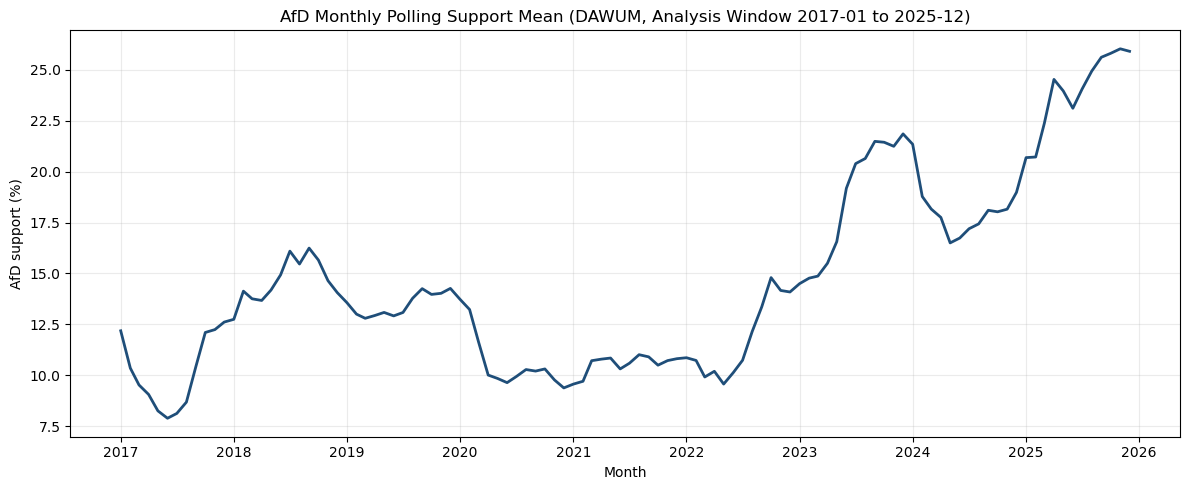

Saved: c:\PythonProjects\AfD-project\figures\02_notebook_figures\afd_polling_monthly_mean.png


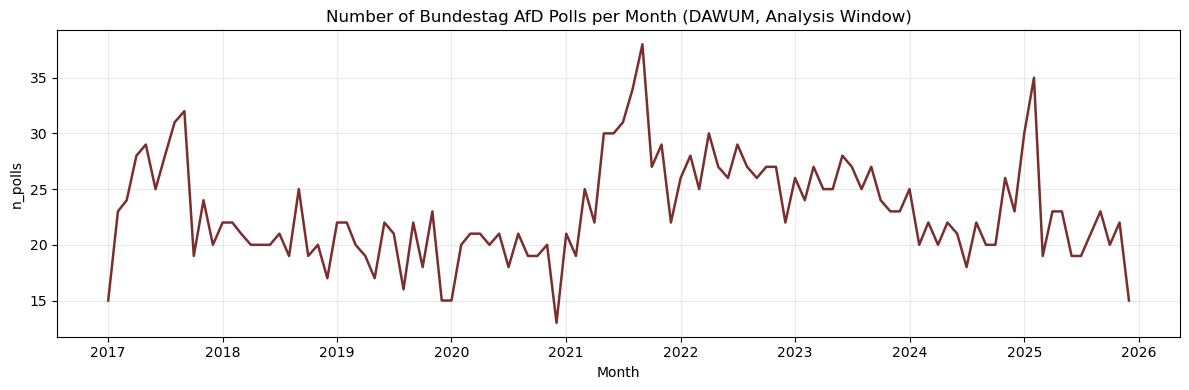

Saved: c:\PythonProjects\AfD-project\figures\02_notebook_figures\afd_polling_n_polls_per_month.png
Missing months in analysis coverage range:
Empty DataFrame
Columns: [missing_month]
Index: []
Total missing months in analysis range: 0
Pollsters by count (top 30):
                      pollster  count
0                         INSA    745
1                        Forsa    478
2               Verian (Emnid)    380
3              Infratest dimap    202
4      Forschungsgruppe Wahlen    182
5                       YouGov    125
6                   Allensbach    116
7                        Civey    113
8                          GMS     79
9                        Ipsos     74
10  Institut Wahlkreisprognose     60
11                    pollytix     10
12      Trend Research Hamburg      7
Coverage summary:
Full DAWUM monthly start: 2017-01-01 00:00:00
Full DAWUM monthly end: 2026-05-01 00:00:00
Analysis monthly start: 2017-01-01 00:00:00
Analysis monthly end: 2025-12-01 00:00:00
Note: DAWU

In [8]:
plot_df = monthly_analysis.copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df['month_dt'], plot_df['afd_poll_support_mean'], color='#1f4e79', linewidth=2)
plt.title('AfD Monthly Polling Support Mean (DAWUM, Analysis Window 2017-01 to 2025-12)')
plt.xlabel('Month')
plt.ylabel('AfD support (%)')
plt.grid(alpha=0.25)
fig1 = FIGURES_DIR / 'afd_polling_monthly_mean.png'
plt.tight_layout()
plt.savefig(fig1, dpi=150)
plt.show()
print('Saved:', fig1)

plt.figure(figsize=(12, 4))
plt.plot(plot_df['month_dt'], plot_df['n_polls'], color='#7a2e2e', linewidth=1.8)
plt.title('Number of Bundestag AfD Polls per Month (DAWUM, Analysis Window)')
plt.xlabel('Month')
plt.ylabel('n_polls')
plt.grid(alpha=0.25)
fig2 = FIGURES_DIR / 'afd_polling_n_polls_per_month.png'
plt.tight_layout()
plt.savefig(fig2, dpi=150)
plt.show()
print('Saved:', fig2)

coverage_months = pd.period_range(plot_df['month_dt'].min(), plot_df['month_dt'].max(), freq='M')
covered = pd.PeriodIndex(plot_df['month_dt'].dt.to_period('M').unique(), freq='M')
missing = coverage_months.difference(covered)
missing_months_df = pd.DataFrame({'missing_month': [m.strftime('%Y-%m') for m in missing]})

pollsters_by_count = polls['pollster'].value_counts(dropna=False).rename_axis('pollster').reset_index(name='count')

print('Missing months in analysis coverage range:')
print(missing_months_df.head(30))
print('Total missing months in analysis range:', len(missing_months_df))

print('Pollsters by count (top 30):')
print(pollsters_by_count.head(30))

print('Coverage summary:')
print('Full DAWUM monthly start:', monthly['month_dt'].min())
print('Full DAWUM monthly end:', monthly['month_dt'].max())
print('Analysis monthly start:', plot_df['month_dt'].min())
print('Analysis monthly end:', plot_df['month_dt'].max())

media_start = pd.Timestamp('2013-01-01')
if plot_df['month_dt'].min() > media_start:
    print('Note: DAWUM starts later than media corpus start (2013-01). Historical supplement may be required for early-period analyses.')
else:
    print('DAWUM starts on or before media corpus start.')